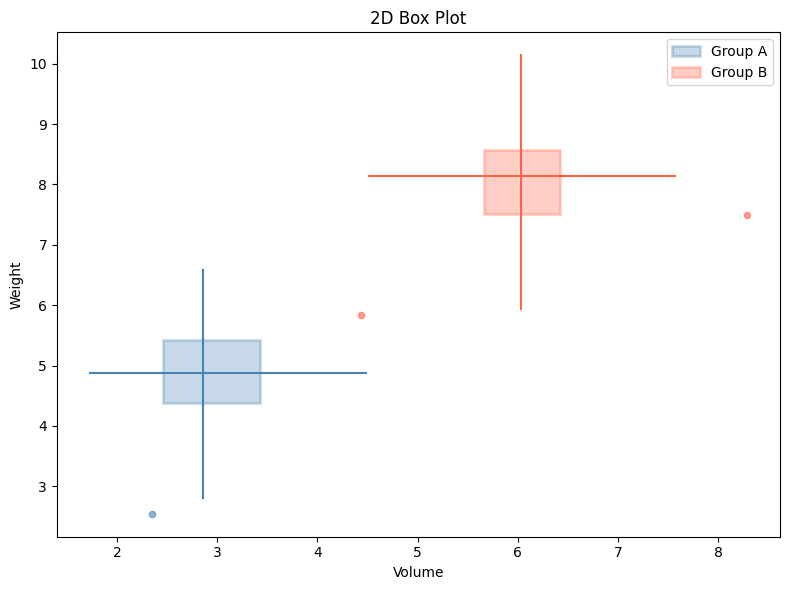

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

np.random.seed(42)

# Two groups of 2D data (volume, weight)
group_a = np.random.multivariate_normal([3, 5], [[0.5, 0.2], [0.2, 0.8]], 100)
group_b = np.random.multivariate_normal([6, 8], [[0.4, 0.1], [0.1, 0.6]], 100)

def draw_2d_boxplot(ax, data, color, label):
    x, y = data[:, 0], data[:, 1]

    # Box boundaries: Q1, Q3 for each dimension
    x_q1, x_q3 = np.percentile(x, 25), np.percentile(x, 75)
    y_q1, y_q3 = np.percentile(y, 25), np.percentile(y, 75)
    x_med, y_med = np.median(x), np.median(y)

    x_iqr = x_q3 - x_q1
    y_iqr = y_q3 - y_q1

    # Whisker limits (1.5 * IQR)
    x_wlo = max(x.min(), x_q1 - 1.5 * x_iqr)
    x_whi = min(x.max(), x_q3 + 1.5 * x_iqr)
    y_wlo = max(y.min(), y_q1 - 1.5 * y_iqr)
    y_whi = min(y.max(), y_q3 + 1.5 * y_iqr)

    # Draw whisker lines (cross shape)
    ax.plot([x_wlo, x_whi], [y_med, y_med], color=color, linewidth=1.5, zorder=2)
    ax.plot([x_med, x_med], [y_wlo, y_whi], color=color, linewidth=1.5, zorder=2)

    # Draw IQR box
    box = patches.FancyBboxPatch(
        (x_q1, y_q1), x_iqr, y_iqr,
        boxstyle="square,pad=0",
        linewidth=2, edgecolor=color,
        facecolor=color, alpha=0.3,
        zorder=3, label=label
    )
    ax.add_patch(box)

    # Draw outliers
    outliers = data[
        (x < x_wlo) | (x > x_whi) | (y < y_wlo) | (y > y_whi)
    ]
    if len(outliers):
        ax.scatter(outliers[:, 0], outliers[:, 1], color=color,
                   s=20, alpha=0.6, zorder=5, marker='o')

fig, ax = plt.subplots(figsize=(8, 6))

draw_2d_boxplot(ax, group_a, color='steelblue', label='Group A')
draw_2d_boxplot(ax, group_b, color='tomato',    label='Group B')

# Scatter the raw points (faint)
#ax.scatter(group_a[:, 0], group_a[:, 1], color='steelblue', alpha=0.15, s=15, zorder=1)
#ax.scatter(group_b[:, 0], group_b[:, 1], color='tomato',    alpha=0.15, s=15, zorder=1)

ax.set_xlabel('Volume')
ax.set_ylabel('Weight')
ax.set_title('2D Box Plot')
ax.legend()
plt.tight_layout()
plt.show()